# Deep Learning HW2
##  Environment Setup

To ensure reproducibility, we recommend creating a dedicated conda environment before running this notebook.

### Step 1. Create a new conda environment

```bash
conda create -n dl_hw2 python=3.10 -y
conda activate dl_hw2
```
### Step 2. Install PyTorch

First, try installing the GPU version. Make sure to install the version that matches your CUDA version.
```bash
pip install --upgrade pip
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
```

Run the commands below to verify that PyTorch GPU version and the required packages have been installed correctly.
```bash
python -c "import sys; print(sys.executable)"
python -c "import torch; print(torch.__version__)"
python -c "import torch; print(torch.cuda.is_available())"
python -c "import numpy; print(numpy.__version__)"
```

If you do not have access to a GPU, install the CPU version instead.
```bash
pip install --upgrade pip
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
```

Run the commands below to verify that PyTorch CPU version and the required packages have been installed correctly.
```bash
python -c "import sys; print(sys.executable)"
python -c "import torch; print(torch.__version__)"
python -c "import numpy; print(numpy.__version__)"
```

##### We strongly recommend using a GPU environment. If you do not have access to a GPU, you may use Google Colab.

In [1]:
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


## Image Segmentation with U-net

#### In this part, you will implement and train a U-Net model for binary image segmentation.

For segmentation, we use the Oxford-IIIT Pet dataset.

Downloading the dataset may take some time during the first run.

The segmentation task is formulated as a binary classification problem at the pixel level.

100.0%


Extracting data/oxford-iiit-pet/images.tar.gz to data/oxford-iiit-pet


100.0%


Extracting data/oxford-iiit-pet/annotations.tar.gz to data/oxford-iiit-pet
Train size: 3680
Test size: 3669
Image batch shape: torch.Size([8, 3, 128, 128])
Mask batch shape: torch.Size([8, 1, 128, 128])
Mask unique values: tensor([0., 1.])


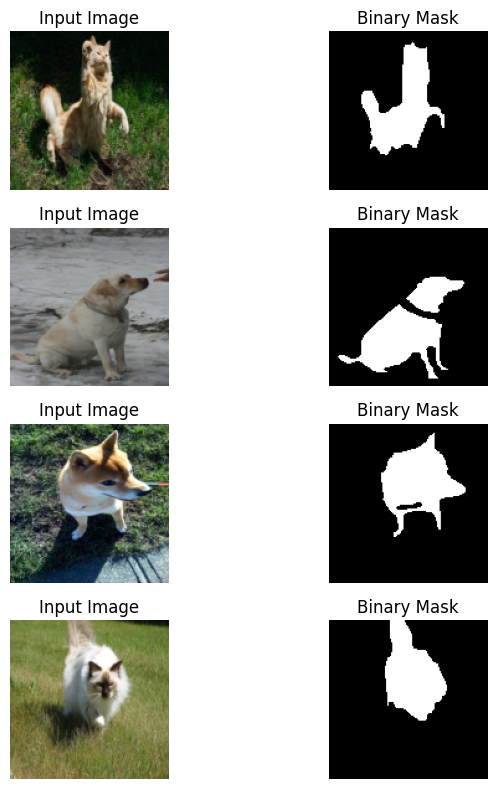

In [2]:
import torch
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF
from PIL import Image
import matplotlib.pyplot as plt


# ============================================================
# 1. Custom transform for binary segmentation mask
# ============================================================

class BinaryMaskTransform:
    def __init__(self, size=(128, 128)):
        self.size = size

    def __call__(self, mask):
        # Resize mask using nearest-neighbor interpolation
        mask = TF.resize(mask, self.size, interpolation=Image.NEAREST)

        # Convert PIL image to tensor without normalization
        mask = torch.as_tensor(TF.pil_to_tensor(mask), dtype=torch.long)
        mask = (mask == 1).float()

        return mask


# ============================================================
# 2. Image / mask transforms
# ============================================================

image_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

mask_transform = BinaryMaskTransform(size=(128, 128))


# ============================================================
# 3. Dataset
# ============================================================

train_dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=image_transform,
    target_transform=mask_transform
)

test_dataset = OxfordIIITPet(
    root="./data",
    split="test",
    target_types="segmentation",
    download=True,
    transform=image_transform,
    target_transform=mask_transform
)


# ============================================================
# 4. DataLoader
# ============================================================

batch_size = 8  # You may change the batch size based on your hardware constraints.

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)


# ============================================================
# 5. Sanity check
# ============================================================

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)   # expected: (B, 3, 128, 128)
print("Mask batch shape:", masks.shape)     # expected: (B, 1, 128, 128)
print("Mask unique values:", torch.unique(masks))  # expected: tensor([0., 1.])


# ============================================================
# 6. Visualization
# ============================================================

def show_samples(images, masks, num_samples=4):
    plt.figure(figsize=(8, 2 * num_samples))

    for i in range(num_samples):
        # image
        plt.subplot(num_samples, 2, 2 * i + 1)
        img = images[i].permute(1, 2, 0).cpu().numpy()
        plt.imshow(img)
        plt.title("Input Image")
        plt.axis("off")

        # mask
        plt.subplot(num_samples, 2, 2 * i + 2)
        mask = masks[i].squeeze().cpu().numpy()
        plt.imshow(mask, cmap="gray")
        plt.title("Binary Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_samples(images, masks, num_samples=4)

In [3]:
# ============================================================
# 1. Building Blocks
# ============================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # TODO:
        # MaxPool2d(2) -> DoubleConv

        self.block = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        # TODO:
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # TODO:
        # Define:
        # 1) ConvTranspose2d for upsampling
        # 2) DoubleConv

        # Upsamples x1 from in_channels to in_channels//2 channels.
        # After concatenation with the skip connection (also in_channels//2),
        # total channels become in_channels, which DoubleConv maps to out_channels.
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        # TODO:
        # x1: decoder feature
        # x2: encoder feature (skip connection)
        #
        # Hint:
        # Upsample x1, then concatenate it with x2 along the channel dimension (dim=1),
        # and apply the convolution block.

        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


# ============================================================
# 2. U-Net
# ============================================================

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # TODO:
        # Define the U-Net architecture.
        #
        # Suggested channels:
        # 3 -> 16 -> 32 -> 64 -> 128 (encoder)
        # 128 -> 64 -> 32 -> 16 (decoder)
        # Final: 16 -> 1

        self.inc   = DoubleConv(3, 16)
        self.down1 = Down(16, 32)
        self.down2 = Down(32, 64)
        self.down3 = Down(64, 128)

        self.up1   = Up(128, 64)
        self.up2   = Up(64, 32)
        self.up3   = Up(32, 16)

        self.outc  = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        # TODO:
        # Implement forward pass with skip connections.
        #
        # Hint:
        # Save encoder features before downsampling,
        # and reuse them in the decoder.

        x1 = self.inc(x)        # (B, 16, 128, 128)
        x2 = self.down1(x1)     # (B, 32,  64,  64)
        x3 = self.down2(x2)     # (B, 64,  32,  32)
        x4 = self.down3(x3)     # (B, 128, 16,  16)  — bottleneck

        x  = self.up1(x4, x3)   # (B, 64,  32,  32)
        x  = self.up2(x,  x2)   # (B, 32,  64,  64)
        x  = self.up3(x,  x1)   # (B, 16, 128, 128)

        return self.outc(x)     # (B,  1, 128, 128)

In [4]:
model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 30

# ============================================================
# 3. Training
# ============================================================

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device).float()

        # TODO:
        # Perform one training step and update total_loss

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")


# ============================================================
# 4. Evaluation
# ============================================================

def pixel_accuracy(preds, targets, eps=1e-8):
    preds = preds.float()
    targets = targets.float()

    # TODO: implement pixel accuracy
    correct = (preds == targets).sum()
    total = targets.numel()
    return (correct / total).item()


def dice_score(preds, targets, eps=1e-8):
    preds = preds.float()
    targets = targets.float()

    # TODO: implement dice score
    intersection = (preds * targets).sum()
    return (2 * intersection / (preds.sum() + targets.sum() + eps)).item()


def binary_miou(preds, targets, eps=1e-8):
    preds = preds.float()
    targets = targets.float()

    # TODO: implement binary mIoU
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return (intersection / (union + eps)).item()


model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device).float()
        
        # TODO:
        # 1. Forward pass (logits)
        # 2. Apply sigmoid
        # 3. Convert to binary predictions (threshold = 0.5)

        logits = model(images)
        probs  = torch.sigmoid(logits)
        preds  = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_targets.append(masks.cpu())


# TODO:
# 1. Concatenate all predictions and targets
# 2. Compute metrics for test dataset

all_preds   = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

mean_pixel_acc = pixel_accuracy(all_preds, all_targets)
mean_dice      = dice_score(all_preds, all_targets)
mean_miou      = binary_miou(all_preds, all_targets)

print(f"Pixel Accuracy: {mean_pixel_acc:.4f}")
print(f"Dice Score: {mean_dice:.4f}")
print(f"mIoU: {mean_miou:.4f}")

Epoch [1/30] | Loss: 0.5485
Epoch [2/30] | Loss: 0.4480
Epoch [3/30] | Loss: 0.4332
Epoch [4/30] | Loss: 0.4248
Epoch [5/30] | Loss: 0.4183
Epoch [6/30] | Loss: 0.4109
Epoch [7/30] | Loss: 0.4031
Epoch [8/30] | Loss: 0.3877
Epoch [9/30] | Loss: 0.3695
Epoch [10/30] | Loss: 0.3467
Epoch [11/30] | Loss: 0.3190
Epoch [12/30] | Loss: 0.3019
Epoch [13/30] | Loss: 0.2971
Epoch [14/30] | Loss: 0.2784
Epoch [15/30] | Loss: 0.2639
Epoch [16/30] | Loss: 0.2566
Epoch [17/30] | Loss: 0.2515
Epoch [18/30] | Loss: 0.2428
Epoch [19/30] | Loss: 0.2355
Epoch [20/30] | Loss: 0.2239
Epoch [21/30] | Loss: 0.2189
Epoch [22/30] | Loss: 0.2140
Epoch [23/30] | Loss: 0.2057
Epoch [24/30] | Loss: 0.2008
Epoch [25/30] | Loss: 0.1963
Epoch [26/30] | Loss: 0.1874
Epoch [27/30] | Loss: 0.1801
Epoch [28/30] | Loss: 0.1761
Epoch [29/30] | Loss: 0.1764
Epoch [30/30] | Loss: 0.1666
Pixel Accuracy: 0.8980
Dice Score: 0.8325
mIoU: 0.7131


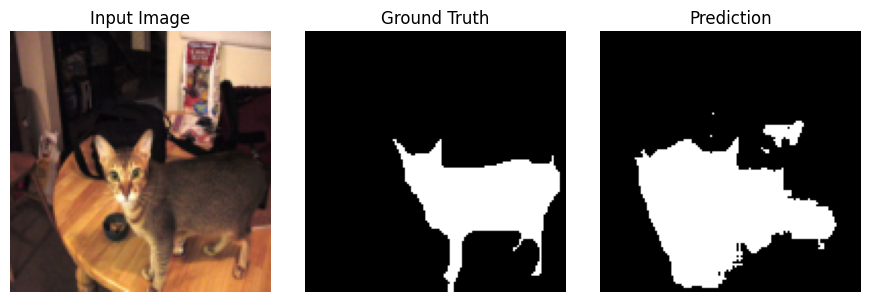

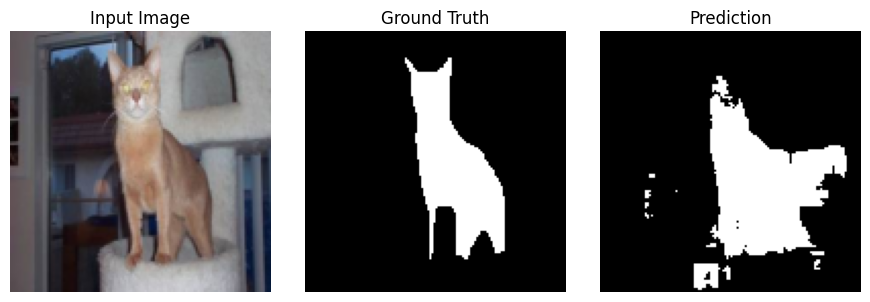

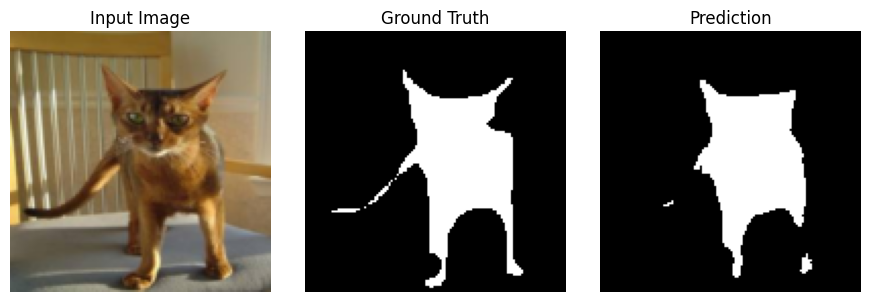

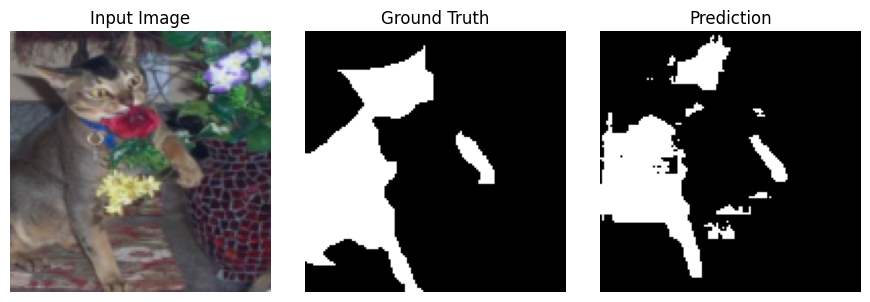

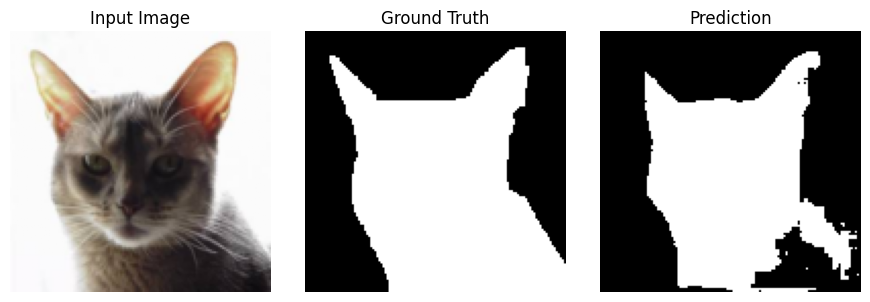

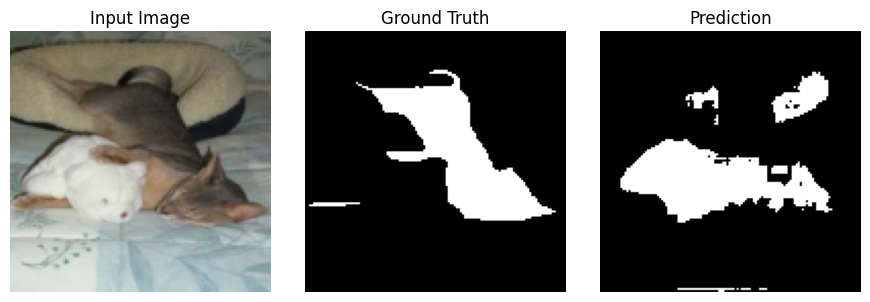

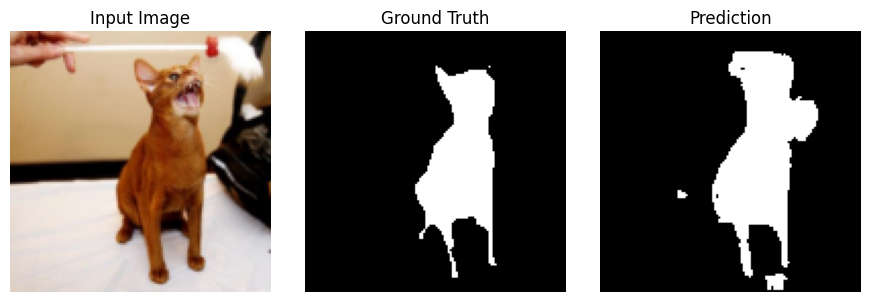

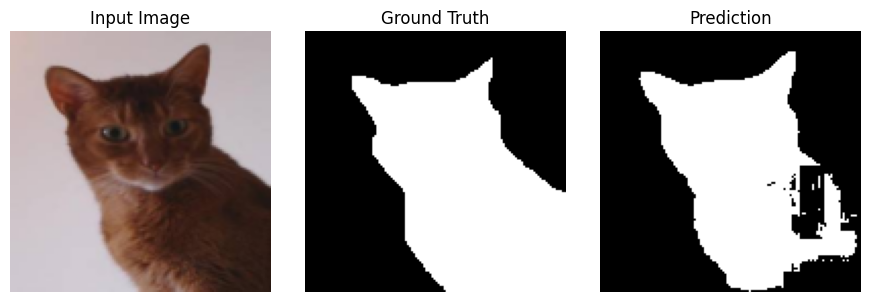

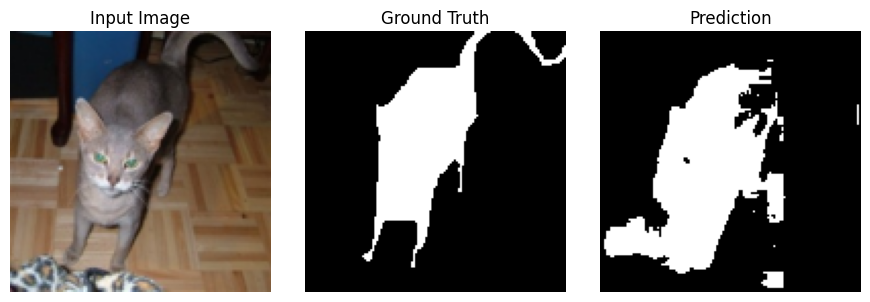

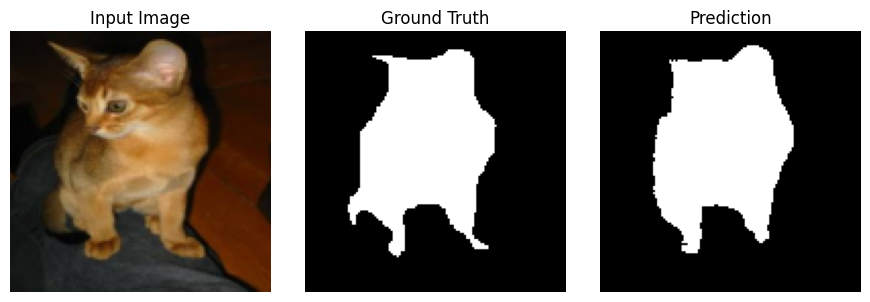

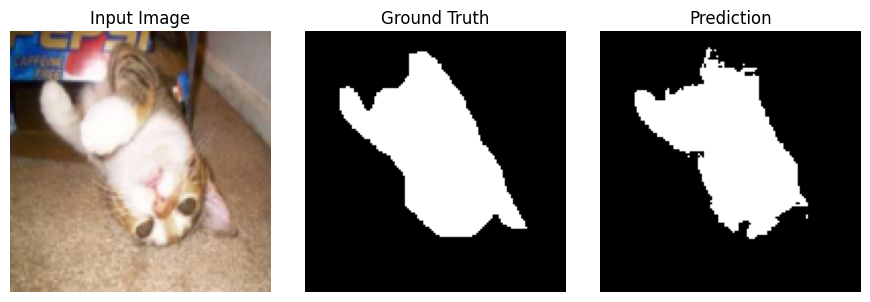

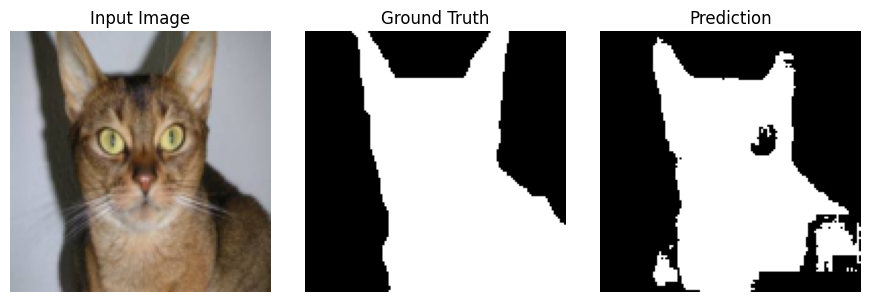

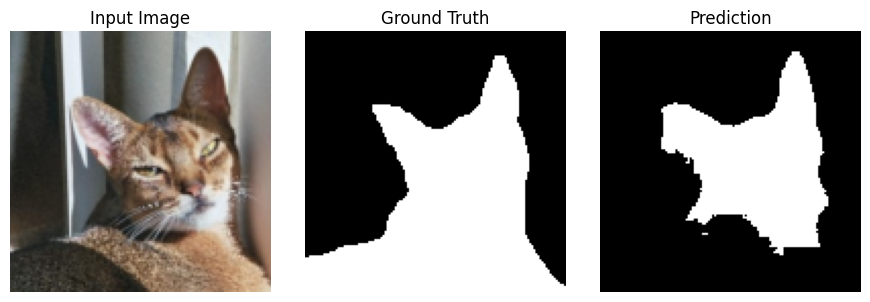

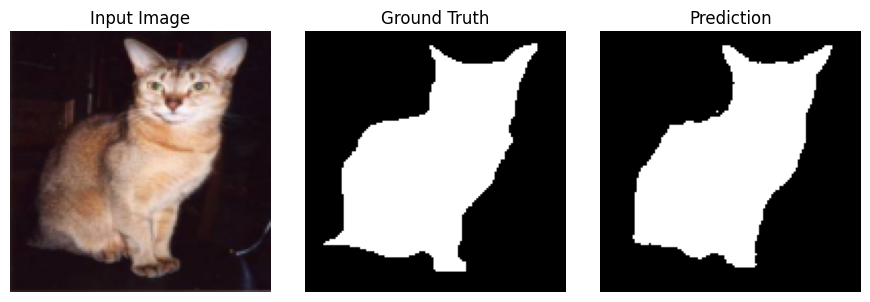

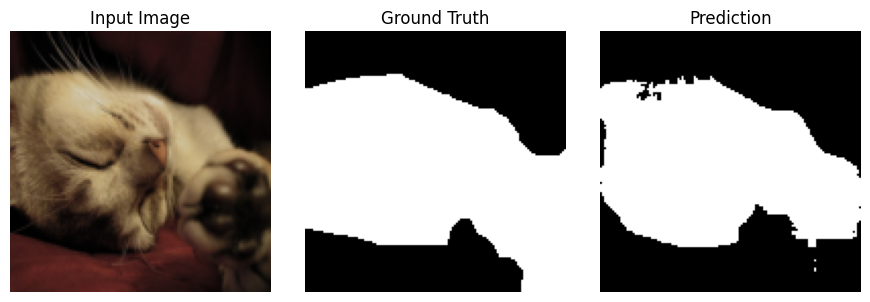

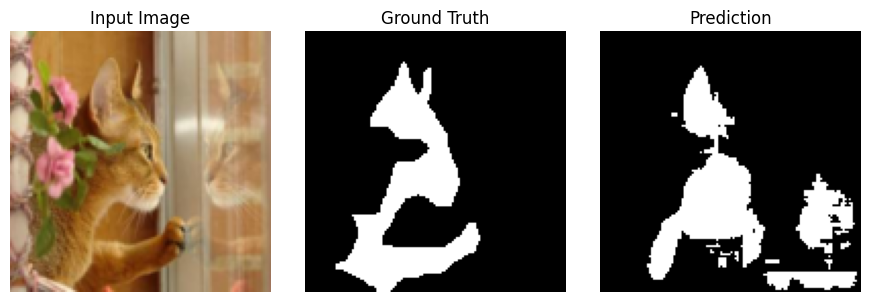

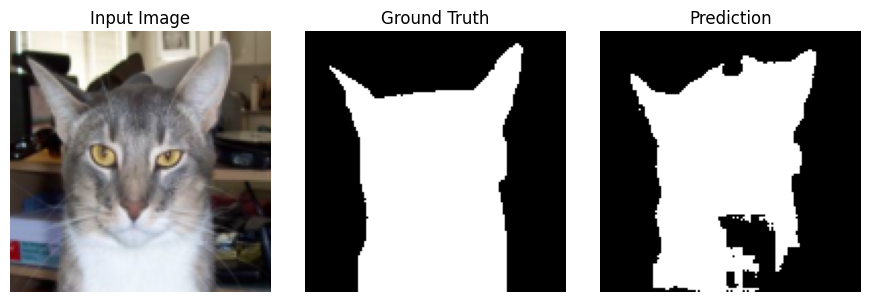

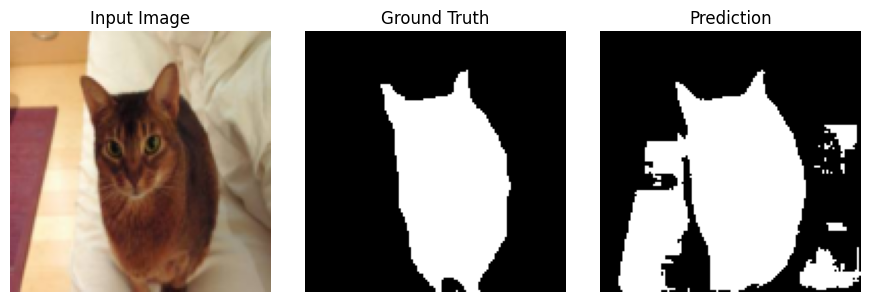

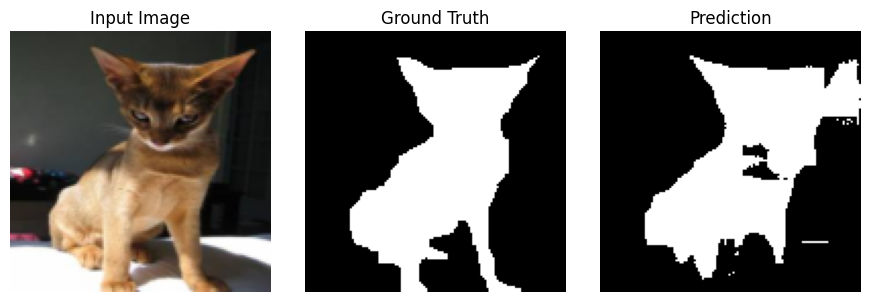

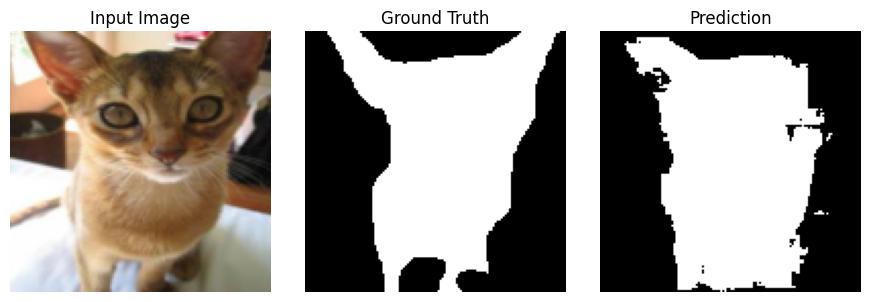

In [5]:
# ============================================================
# 5. Visualization
# ============================================================

def visualize_predictions(model, dataloader, device, num_examples=5):
    model.eval()
    shown = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device).float()

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            for i in range(images.size(0)):
                if shown >= num_examples:
                    return

                image = images[i].cpu().permute(1, 2, 0).numpy()
                mask = masks[i].cpu().squeeze().numpy()
                pred = preds[i].cpu().squeeze().numpy()

                plt.figure(figsize=(9, 3))

                plt.subplot(1, 3, 1)
                plt.imshow(image)
                plt.title("Input Image")
                plt.axis("off")

                plt.subplot(1, 3, 2)
                plt.imshow(mask, cmap="gray")
                plt.title("Ground Truth")
                plt.axis("off")

                plt.subplot(1, 3, 3)
                plt.imshow(pred, cmap="gray")
                plt.title("Prediction")
                plt.axis("off")

                plt.tight_layout()
                plt.show()

                shown += 1

visualize_predictions(model, test_loader, device, num_examples=20)

## Name Classification with RNN

#### In this part, you will implement and train a RNN for sequence classification.

For the RNN task, we use the name classification dataset provided in the PyTorch tutorials.

The task is formulated as a sequence classification problem, where each input name is represented as a sequence of characters and the model predicts its corresponding category.

In [6]:
import os
import zipfile
import urllib.request
import glob
import string
import unicodedata

url = "https://download.pytorch.org/tutorial/data.zip"
filename = "rnn_data.zip"

if not os.path.exists(filename):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, filename)
    print("Download complete.")

if not os.path.exists("rnn_data"):
    print("Extracting dataset...")
    with zipfile.ZipFile(filename, "r") as zip_ref:
        zip_ref.extractall("rnn_data")
    print("Extraction complete.")

Download complete.
Extracting dataset...
Extraction complete.


In [7]:
# ============================================================
# 1. Load dataset (text files → category-wise names)
# ============================================================

data_dir = "rnn_data/data/names"

category_lines = {}   # dict: {category: [names]}
all_categories = []   # list of category names

for filename in glob.glob(os.path.join(data_dir, "*.txt")):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)

    with open(filename, encoding="utf-8") as f:
        lines = f.read().strip().split("\n")
        category_lines[category] = lines

all_categories = sorted(all_categories)

print("Number of categories:", len(all_categories))
print("Categories:", all_categories)


# ============================================================
# 2. Convert unicode strings to ASCII
# ============================================================

def unicode_to_ascii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# Apply conversion to all names
for category in all_categories:
    category_lines[category] = [
        unicode_to_ascii(name) for name in category_lines[category]
    ]


# ============================================================
# 3. Build character vocabulary
# ============================================================

all_letters = string.ascii_letters + " .,;'-"
PAD_TOKEN = "<PAD>"

char2idx = {PAD_TOKEN: 0}  # padding index = 0
for i, ch in enumerate(all_letters, start=1):
    char2idx[ch] = i

idx2char = {i: ch for ch, i in char2idx.items()}

n_chars = len(char2idx)
print("Number of characters:", n_chars)
print("Characters:", char2idx)


# ============================================================
# 4. Build label mapping (category → index)
# ============================================================

label2idx = {label: i for i, label in enumerate(all_categories)}
idx2label = {i: label for label, i in label2idx.items()}

# ============================================================
# 5. Convert dataset into (name, label) pairs
# ============================================================

data = []

for category in all_categories:
    for name in category_lines[category]:
        if len(name) > 0:
            data.append((name, category))

print("Total samples:", len(data))
print(data[:5])


# ============================================================
# 6. Train / Test split
# ============================================================
random.shuffle(data)

split = int(0.8 * len(data))
train_data = data[:split]
test_data = data[split:]

print("Train:", len(train_data))
print("Test:", len(test_data))


# ============================================================
# 7. Encode names into sequences of character indices
# ============================================================

def encode_name(name):
    return [char2idx[ch] for ch in name if ch in char2idx]


# ============================================================
# 8. Dataset class
# ============================================================

class NameDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        name, label = self.data[idx]

        name_ids = encode_name(name)      # sequence of indices
        label_id = label2idx[label]       # class index

        return (
            torch.tensor(name_ids, dtype=torch.long),
            torch.tensor(label_id, dtype=torch.long)
        )


# ============================================================
# 9. Collate function (padding variable-length sequences)
# ============================================================

def collate_fn(batch):
    names, labels = zip(*batch)

    lengths = [len(n) for n in names]
    max_len = max(lengths)

    padded = []
    for n in names:
        pad_len = max_len - len(n)
        padded.append(torch.cat([n, torch.zeros(pad_len, dtype=torch.long)]))

    padded = torch.stack(padded)   # (B, T)
    labels = torch.stack(labels)   # (B,)
    lengths = torch.tensor(lengths)

    return padded, labels, lengths


# ============================================================
# 10. DataLoader
# ============================================================

train_dataset = NameDataset(train_data)
test_dataset = NameDataset(test_data)

batch_size = 32  # You may change the batch size based on your hardware constraints.
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)


# ============================================================
# 11. Sanity check (check batch shapes)
# ============================================================

names, labels, lengths = next(iter(train_loader))

print("Names:", names.shape)     # (B, T)
print("Labels:", labels.shape)   # (B,)
print("Lengths:", lengths.shape) # (B,)

Number of categories: 18
Categories: ['Arabic', 'Chinese', 'Czech', 'Dutch', 'English', 'French', 'German', 'Greek', 'Irish', 'Italian', 'Japanese', 'Korean', 'Polish', 'Portuguese', 'Russian', 'Scottish', 'Spanish', 'Vietnamese']
Number of characters: 59
Characters: {'<PAD>': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, 'A': 27, 'B': 28, 'C': 29, 'D': 30, 'E': 31, 'F': 32, 'G': 33, 'H': 34, 'I': 35, 'J': 36, 'K': 37, 'L': 38, 'M': 39, 'N': 40, 'O': 41, 'P': 42, 'Q': 43, 'R': 44, 'S': 45, 'T': 46, 'U': 47, 'V': 48, 'W': 49, 'X': 50, 'Y': 51, 'Z': 52, ' ': 53, '.': 54, ',': 55, ';': 56, "'": 57, '-': 58}
Total samples: 20074
[('Khoury', 'Arabic'), ('Nahas', 'Arabic'), ('Daher', 'Arabic'), ('Gerges', 'Arabic'), ('Nazari', 'Arabic')]
Train: 16059
Test: 4015
Names: torch.Size([32, 13])
Labels: torch.Size([32])

In [8]:
# ============================================================
# 1. RNN Model
# ============================================================

class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()

        self.hidden_size = hidden_size

        # TODO:
        # Define trainable parameters for:
        # x_t -> h_t
        # h_{t-1} -> h_t
        # h_t -> output

        self.W_xh = nn.Parameter(torch.empty(input_size, hidden_size))   # shape: (input_size, hidden_size)
        self.W_hh = nn.Parameter(torch.empty(hidden_size, hidden_size))  # shape: (hidden_size, hidden_size)
        self.b_h  = nn.Parameter(torch.zeros(hidden_size))               # shape: (hidden_size,)

        self.W_hy = nn.Parameter(torch.empty(hidden_size, num_classes))  # shape: (hidden_size, num_classes)
        self.b_y  = nn.Parameter(torch.zeros(num_classes))               # shape: (num_classes,)

        self.reset_parameters()

    def forward(self, x, lengths):
        """
        x: (B, T) character indices
        lengths: (B,)
        """

        # TODO:
        # 1. Convert x to one-hot vectors: (B, T, input_size)
        # 2. Initialize hidden state h0 with zeros: (B, hidden_size)
        # 3. For each time step t:
        #       h_t = tanh(x_t W_xh + h_{t-1} W_hh + b_h)
        # 4. Use the last valid hidden state for each sequence
        # 5. Compute logits: h_T W_hy + b_y

        B, T = x.shape

        # 1. One-hot encode: (B, T, input_size)
        x_onehot = F.one_hot(x, num_classes=self.W_xh.shape[0]).float()

        # 2. Initialize hidden state
        h = torch.zeros(B, self.hidden_size, device=x.device)

        # 3. Unroll RNN and collect all hidden states
        hidden_states = []
        for t in range(T):
            x_t = x_onehot[:, t, :]                                  # (B, input_size)
            h = torch.tanh(x_t @ self.W_xh + h @ self.W_hh + self.b_h)
            hidden_states.append(h)

        # hidden_states: (B, T, hidden_size)
        hidden_states = torch.stack(hidden_states, dim=1)

        # 4. Gather the hidden state at each sequence's last valid time step
        idx = (lengths - 1).clamp(min=0).long().to(x.device)         # (B,)
        idx = idx.view(B, 1, 1).expand(B, 1, self.hidden_size)
        last_h = hidden_states.gather(1, idx).squeeze(1)              # (B, hidden_size)

        # 5. Output logits
        return last_h @ self.W_hy + self.b_y                         # (B, num_classes)

    
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.W_xh)
        nn.init.xavier_uniform_(self.W_hh)
        nn.init.xavier_uniform_(self.W_hy)
        nn.init.zeros_(self.b_h)
        nn.init.zeros_(self.b_y)

In [9]:
model = RNNClassifier(
    input_size=n_chars,
    hidden_size=128,
    num_classes=len(all_categories)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 40

# ============================================================
# 3. Training
# ============================================================

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for names, labels, lengths in train_loader:
        names = names.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)

        # TODO:
        # 1. Forward pass
        # 2. Compute loss
        # 3. Backward pass
        # 4. Update parameters
        # 5. Compute accuracy

    
        optimizer.zero_grad()
        outputs = model(names, lengths)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    acc = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%")


# ============================================================
# 4. Evaluation
# ============================================================

def macro_f1(preds, targets, eps=1e-8):
    preds = preds.float()
    targets = targets.float()

    # TODO: implement macro-F1
    num_classes = int(max(preds.max(), targets.max()).item()) + 1
    f1_scores = []
    for c in range(num_classes):
        pred_c   = (preds == c).float()
        target_c = (targets == c).float()
        tp = (pred_c * target_c).sum()
        fp = (pred_c * (1 - target_c)).sum()
        fn = ((1 - pred_c) * target_c).sum()
        precision = tp / (tp + fp + eps)
        recall    = tp / (tp + fn + eps)
        f1_scores.append(2 * precision * recall / (precision + recall + eps))
    return torch.stack(f1_scores).mean().item()

model.eval()

correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for names, labels, lengths in test_loader:
        names = names.to(device)
        labels = labels.to(device)

        # TODO:
        # 1. Forward pass
        # 2. Get predicted labels
        # Hint : Store predictions and labels across all batches for F1 computation

        outputs = model(names, lengths.to(device))
        _, preds_batch = torch.max(outputs, 1)

        correct += (preds_batch == labels).sum().item()
        total += labels.size(0)

        all_preds.append(preds_batch.cpu())
        all_labels.append(labels.cpu())


# Accuracy
test_acc = 100 * correct / total

# TODO:
# Compute Macro-F1 using macro_f1()
all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
mean_f1 = macro_f1(all_preds, all_labels)

print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Macro-F1: {mean_f1:.4f}")

Epoch [1/40] | Loss: 1.2682 | Acc: 64.15%
Epoch [2/40] | Loss: 0.9172 | Acc: 73.16%
Epoch [3/40] | Loss: 0.8048 | Acc: 75.86%
Epoch [4/40] | Loss: 0.7436 | Acc: 77.36%
Epoch [5/40] | Loss: 0.6987 | Acc: 78.60%
Epoch [6/40] | Loss: 0.6568 | Acc: 79.75%
Epoch [7/40] | Loss: 0.6227 | Acc: 80.43%
Epoch [8/40] | Loss: 0.5919 | Acc: 81.42%
Epoch [9/40] | Loss: 0.5644 | Acc: 82.32%
Epoch [10/40] | Loss: 0.5341 | Acc: 82.99%
Epoch [11/40] | Loss: 0.5045 | Acc: 83.98%
Epoch [12/40] | Loss: 0.4854 | Acc: 84.26%
Epoch [13/40] | Loss: 0.4647 | Acc: 84.72%
Epoch [14/40] | Loss: 0.4404 | Acc: 85.88%
Epoch [15/40] | Loss: 0.4202 | Acc: 86.15%
Epoch [16/40] | Loss: 0.3978 | Acc: 86.83%
Epoch [17/40] | Loss: 0.3813 | Acc: 87.70%
Epoch [18/40] | Loss: 0.3641 | Acc: 87.92%
Epoch [19/40] | Loss: 0.3510 | Acc: 88.24%
Epoch [20/40] | Loss: 0.3285 | Acc: 89.19%
Epoch [21/40] | Loss: 0.3166 | Acc: 89.49%
Epoch [22/40] | Loss: 0.3046 | Acc: 89.75%
Epoch [23/40] | Loss: 0.2928 | Acc: 90.18%
Epoch [24/40] | Loss

In [10]:
# ============================================================
# 5. Prediction (Example outputs)
# ============================================================

def decode_name(name_tensor):
    chars = []
    for idx in name_tensor:
        idx = idx.item()
        if idx == 0:  # PAD
            continue
        chars.append(idx2char[idx])
    return "".join(chars)


def show_predictions(model, dataloader, device, num_samples=10):
    model.eval()

    shown = 0

    with torch.no_grad():
        for names, labels, lengths in dataloader:
            names = names.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)

            outputs = model(names, lengths)
            _, preds = torch.max(outputs, 1)

            batch_size = names.size(0)

            for i in range(batch_size):
                if shown >= num_samples:
                    return

                name_str = decode_name(names[i].cpu())
                true_label = idx2label[labels[i].item()]
                pred_label = idx2label[preds[i].item()]

                print(f"{name_str:15s} | GT: {true_label:10s} | Pred: {pred_label}")

                shown += 1


show_predictions(model, test_loader, device, num_samples=10)

Dufour          | GT: English    | Pred: French
Gorbulin        | GT: Russian    | Pred: French
Wheeler         | GT: English    | Pred: Dutch
Storey          | GT: English    | Pred: English
Agakhanyan      | GT: Russian    | Pred: Russian
Hanari          | GT: Japanese   | Pred: Arabic
Vuu             | GT: Vietnamese | Pred: Russian
Amerighi        | GT: Italian    | Pred: Russian
Rahal           | GT: Arabic     | Pred: Arabic
Hennessy        | GT: English    | Pred: English


In [11]:
test_counts = {cat: 0 for cat in all_categories}
for _, cat in test_data:
    test_counts[cat] += 1

total_test  = len(test_data)
sorted_cats = sorted(test_counts.items(), key=lambda x: -x[1])

print("\n[Per-class test distribution and model F1]")
print(f"  {'Language':<12} {'Count':>6}  {'Share':>7}  {'F1 (model)':>11}")
print(f"  {'-'*12} {'-'*6}  {'-'*7}  {'-'*11}")

eps = 1e-8
for cat, cnt in sorted_cats:
    c        = label2idx[cat]
    pred_c   = (all_preds == c).float()
    target_c = (all_labels == c).float()
    tp  = (pred_c * target_c).sum().item()
    fp  = (pred_c * (1 - target_c)).sum().item()
    fn  = ((1 - pred_c) * target_c).sum().item()
    prec = tp / (tp + fp + eps)
    rec  = tp / (tp + fn + eps)
    f1   = 2 * prec * rec / (prec + rec + eps)
    print(f"  {cat:<12} {cnt:>6}  {cnt/total_test:>6.1%}  {f1:>11.4f}")

majority_cat  = sorted_cats[0][0];  majority_n = sorted_cats[0][1]
minority_cat  = sorted_cats[-1][0]; minority_n = sorted_cats[-1][1]
imbalance     = majority_n / minority_n
print(f"\n  Imbalance ratio : {majority_cat} ({majority_n}) vs "
      f"{minority_cat} ({minority_n}) = {imbalance:.1f}x")
print(f"  Test Accuracy   : {test_acc:.2f}%")
print(f"  Macro-F1        : {mean_f1:.4f}")


[Per-class test distribution and model F1]
  Language      Count    Share   F1 (model)
  ------------ ------  -------  -----------
  Russian        1896   47.2%       0.9173
  English         707   17.6%       0.7345
  Arabic          379    9.4%       0.9656
  Japanese        216    5.4%       0.7734
  German          141    3.5%       0.3933
  Italian         127    3.2%       0.6449
  Czech           112    2.8%       0.3254
  Spanish          67    1.7%       0.2523
  Dutch            64    1.6%       0.4966
  Chinese          59    1.5%       0.6306
  Irish            56    1.4%       0.4167
  French           49    1.2%       0.2195
  Greek            49    1.2%       0.6517
  Polish           24    0.6%       0.2500
  Korean           20    0.5%       0.1765
  Portuguese       20    0.5%       0.0556
  Scottish         18    0.4%       0.0000
  Vietnamese       11    0.3%       0.1667

  Imbalance ratio : Russian (1896) vs Vietnamese (11) = 172.4x
  Test Accuracy   : 78.88%
  M

In some cases, the test accuracy may be relatively high, while the Macro-F1 score is significantly lower.

## Analysis : Per Class distribution and F1 in the test split
### Count samples per class in the test split

```python
test_counts = {cat: 0 for cat in all_categories}
for _, cat in test_data:
    test_counts[cat] += 1

total_test  = len(test_data)
sorted_cats = sorted(test_counts.items(), key=lambda x: -x[1])

print("\n[Per-class test distribution and model F1]")
print(f"  {'Language':<12} {'Count':>6}  {'Share':>7}  {'F1 (model)':>11}")
print(f"  {'-'*12} {'-'*6}  {'-'*7}  {'-'*11}")

eps = 1e-8
for cat, cnt in sorted_cats:
    c        = label2idx[cat]
    pred_c   = (all_preds == c).float()
    target_c = (all_labels == c).float()
    tp  = (pred_c * target_c).sum().item()
    fp  = (pred_c * (1 - target_c)).sum().item()
    fn  = ((1 - pred_c) * target_c).sum().item()
    prec = tp / (tp + fp + eps)
    rec  = tp / (tp + fn + eps)
    f1   = 2 * prec * rec / (prec + rec + eps)
    print(f"  {cat:<12} {cnt:>6}  {cnt/total_test:>6.1%}  {f1:>11.4f}")

majority_cat  = sorted_cats[0][0];  majority_n = sorted_cats[0][1]
minority_cat  = sorted_cats[-1][0]; minority_n = sorted_cats[-1][1]
imbalance     = majority_n / minority_n
print(f"\n  Imbalance ratio : {majority_cat} ({majority_n}) vs "
      f"{minority_cat} ({minority_n}) = {imbalance:.1f}x")
print(f"  Test Accuracy   : {test_acc:.2f}%")
print(f"  Macro-F1        : {mean_f1:.4f}")
```
```
[Per-class test distribution and model F1]
  Language      Count    Share   F1 (model)
  ------------ ------  -------  -----------
  Russian        1896   47.2%       0.9173
  English         707   17.6%       0.7345
  Arabic          379    9.4%       0.9656
  Japanese        216    5.4%       0.7734
  German          141    3.5%       0.3933
  Italian         127    3.2%       0.6449
  Czech           112    2.8%       0.3254
  Spanish          67    1.7%       0.2523
  Dutch            64    1.6%       0.4966
  Chinese          59    1.5%       0.6306
  Irish            56    1.4%       0.4167
  French           49    1.2%       0.2195
  Greek            49    1.2%       0.6517
  Polish           24    0.6%       0.2500
  Korean           20    0.5%       0.1765
  Portuguese       20    0.5%       0.0556
  Scottish         18    0.4%       0.0000
  Vietnamese       11    0.3%       0.1667

  Imbalance ratio : Russian (1896) vs Vietnamese (11) = 172.4x
  Test Accuracy   : 78.88%
  Macro-F1        : 0.4484
```
**Question:**  
Explain why this phenomenon occurs.  

**Answer:**
* As shown in the per-class distribution table above, the root cause is severe class imbalance in the test split.
  * The test set (4015 samples) is dominated by Russian, which accounts for 47.2% of all test samples (1896 samples).
  The smallest class, Vietnamese, has only 11 samples (0.3%) — an imbalance ratio of 172.4x.

* Why accuracy stays high
  * `Accuracy = (correct predictions) / (total predictions)` is sample-count weighted. 
  * A correct prediction on the majority class contributes far more to the total score than a correct prediction on a rare class. 
  * A model that performs well on high-frequency languages scores high on accuracy even if it fails entirely on rare ones.

* Why Macro-F1 collapses
  * Macro-F1 computes F1 independently for each of the 18 classes and takes an unweighted average so every class contributes equally regardless of sample count. 
  * Low frequency classes (Scottish: F1=0.0000, Portuguese: F1=0.0556, Vietnamese: F1=0.1667) drag the mean far below even though the high frequency class F1 score is very high (Russian: F1=0.9173, Arabic: F1=0.9656) would suggest.